# Day 06 - Simple RNN for AirPassengers Forecasting

## Objective

The objective of this notebook is to understand the implementation of a Simple Recurrent Neural Network (RNN) for Time Series Forecasting.

The AirPassengers dataset is used to predict future airline passenger counts based on historical data.

## Concepts Covered

- Time Series Data
- Sequential Data
- Recurrent Neural Networks (RNN)
- Data Normalization
- Sequence Creation
- Model Training
- Forecasting
- Prediction Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
print(df.shape)

df.info()

(144, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


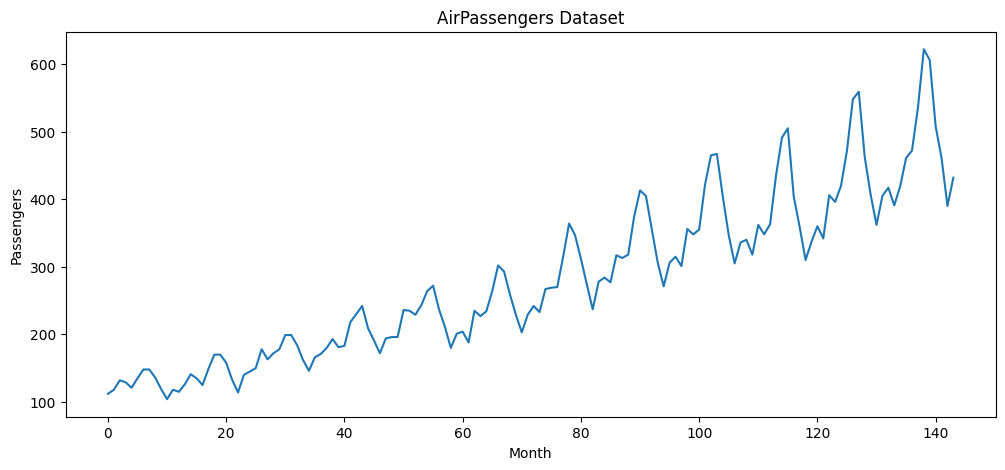

In [4]:
plt.figure(figsize=(12,5))

plt.plot(df['Passengers'])

plt.title("AirPassengers Dataset")
plt.xlabel("Month")
plt.ylabel("Passengers")

plt.show()

## Data Preprocessing

The passenger values are scaled between 0 and 1 using MinMaxScaler.

This improves neural network training performance.

In [5]:
data = df['Passengers'].values.reshape(-1,1)

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

print(data_scaled[:5])

[[0.01544402]
 [0.02702703]
 [0.05405405]
 [0.04826255]
 [0.03281853]]


In [6]:
def create_sequences(data, time_steps=5):

    X = []
    y = []

    for i in range(len(data)-time_steps):

        X.append(data[i:i+time_steps])

        y.append(data[i+time_steps])

    return np.array(X), np.array(y)

In [7]:
X, y = create_sequences(data_scaled, 5)

print(X.shape)
print(y.shape)

(139, 5, 1)
(139, 1)


In [8]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(111, 5, 1)
(28, 5, 1)


## Building Simple RNN Model

In [9]:
model = Sequential()

model.add(
    SimpleRNN(
        units=50,
        activation='tanh',
        input_shape=(5,1)
    )
)

model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test,y_test),
    verbose=1
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0340 - val_loss: 0.0441
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0150 - val_loss: 0.0381
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0107 - val_loss: 0.0331
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0095 - val_loss: 0.0295
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0089 - val_loss: 0.0266
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0078 - val_loss: 0.0241
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0070 - val_loss: 0.0251
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0072 - val_loss: 0.0206
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - val_loss: 0.0194
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0081 - val_loss: 0.0201
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0061 - val_loss: 0.0190
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058 - val_l

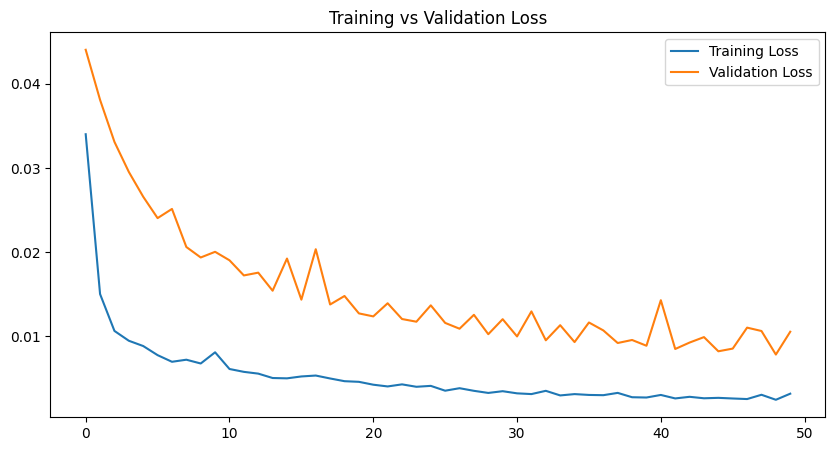

In [12]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],label='Training Loss')

plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()

plt.title("Training vs Validation Loss")

plt.show()

## Model Prediction

In [13]:
predictions = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step


In [14]:
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y_test)

In [15]:
rmse = np.sqrt(
    mean_squared_error(actual,predictions)
)

print("RMSE:",rmse)

RMSE: 53.23998805972835


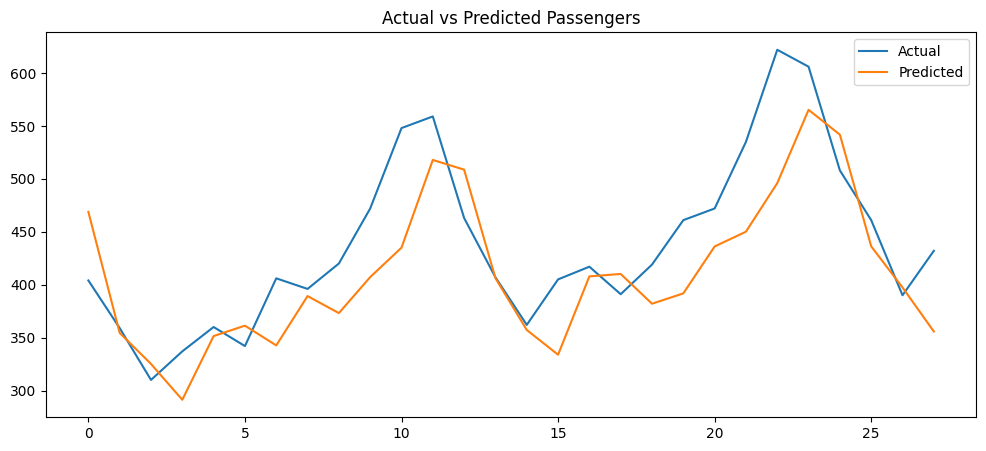

In [16]:
plt.figure(figsize=(12,5))

plt.plot(actual,label='Actual')

plt.plot(predictions,label='Predicted')

plt.title("Actual vs Predicted Passengers")

plt.legend()

plt.show()

# Conclusion

A Simple Recurrent Neural Network (RNN) was implemented on the AirPassengers dataset for time series forecasting.

The model learned patterns from historical passenger data and successfully predicted future passenger counts.

This experiment demonstrated the use of RNNs for sequence modeling and forecasting problems.